# Calculation of Cs atom properties

In [1]:
from arc import Cesium, DynamicPolarizability
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import physical_constants

bohr = physical_constants['Bohr radius'][0]

atom = Cesium()

### Hot atomic vapor data

In [9]:
oven_temperature = 60

print(
        "Oven temperature is {} deg C\n"
        "Pressure: {} Pa\n"
        "Interatomic spacing: {} m\n"
        "Number density: {} /um^3\n"
        "Speed: {} m/s".format(
            oven_temperature,
            atom.getPressure(273.15 + oven_temperature),
            atom.getAverageInteratomicSpacing(273.15 + oven_temperature),
            atom.getNumberDensity(273.15 + oven_temperature)*1e-18,
            atom.getMostProbableSpeed(273.15 + oven_temperature)
            )
    )

Oven temperature is 60 deg C
Pressure: 0.0047337192625051564 Pa
Interatomic spacing: 5.502596855061258e-07 m
Number density: 1.0291517049237606 /um^3
Speed: 144.36622590683845 m/s


### Electron radial wavefunction

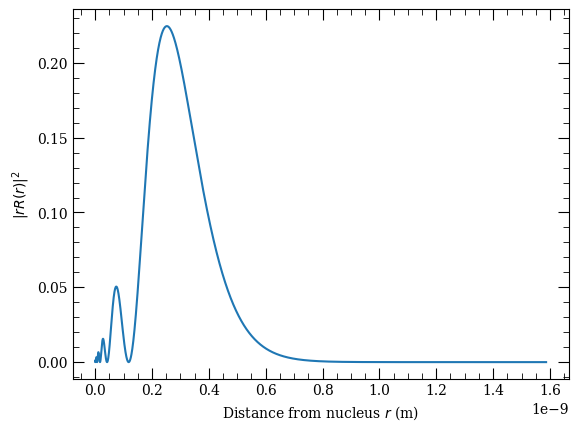

In [3]:
step = 0.001
a1, b1 = atom.radialWavefunction(
    0,
    0.5,
    0.5,
    atom.getEnergy(6, 0, 0.5) / 27.211,
    0,
    30,
    step,
)
plt.plot(
    a1 * bohr, (b1) * (b1), "-"
)

plt.xlabel(r"Distance from nucleus $r$ (m)")
plt.ylabel(r"$\vert rR(r)\vert^2$")
plt.show()

### Dynamic polarizability

In [4]:
calc = DynamicPolarizability(atom, 6, 0, 1/2)
calc.defineBasis(6, 20)

In [6]:
alpha0, alpha1, alpha2, alpha_core, alpha_p, closest_state = calc.getPolarizability(935e-9, accountForStateLifetime=True)
alpha1

-4.104220654741616e-05

In [ ]:
calc.basis

In [ ]:
calc.lifetimes